<a href="https://colab.research.google.com/github/naabiiill/Machine_Learning/blob/main/Unsupervised_Learning_Hierarchical_Clustering_%26_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Hierarchical Clustering & DBSCAN | UNDERFIT | OVERFIT

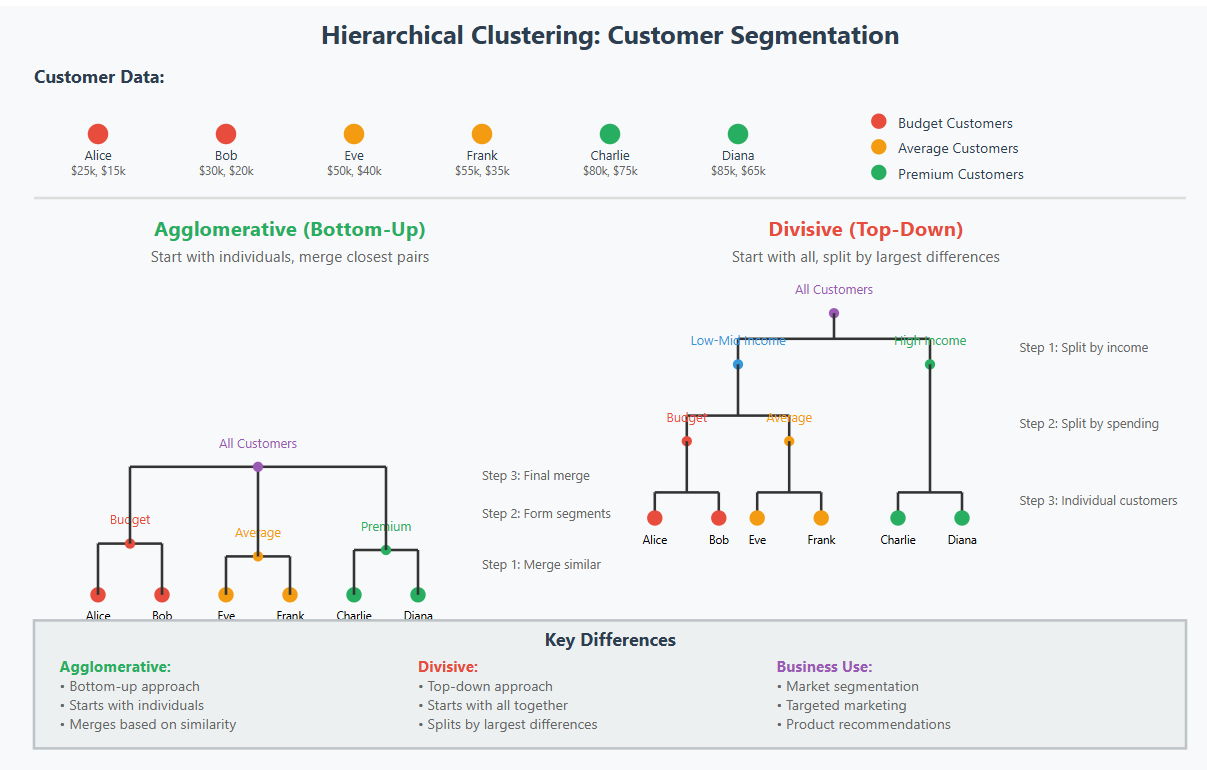![image.png]()

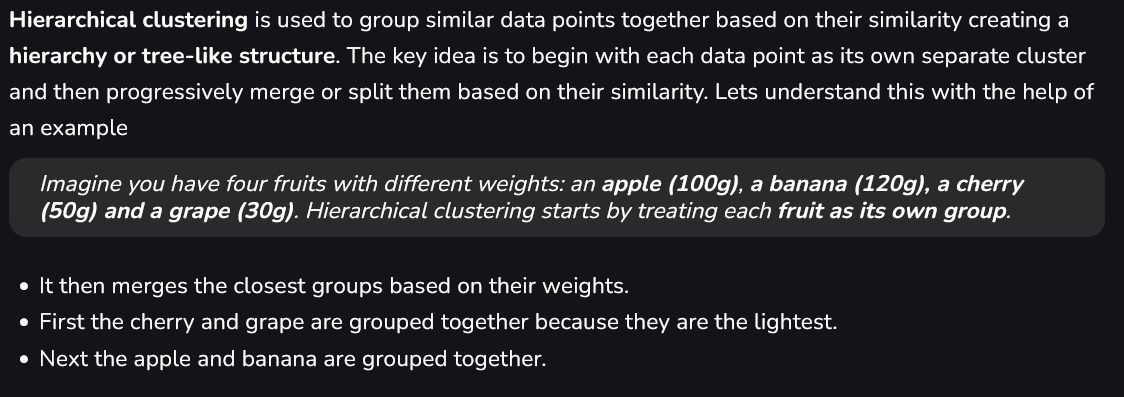

### 📚 Theory: Hierarchical Clustering
## Hierarchical Clustering builds a tree (dendrogram) of clusters without needing to specify the number of clusters.
## Two main types:
## - **Agglomerative** (bottom-up): Start with each point as its own cluster, merge closest pairs
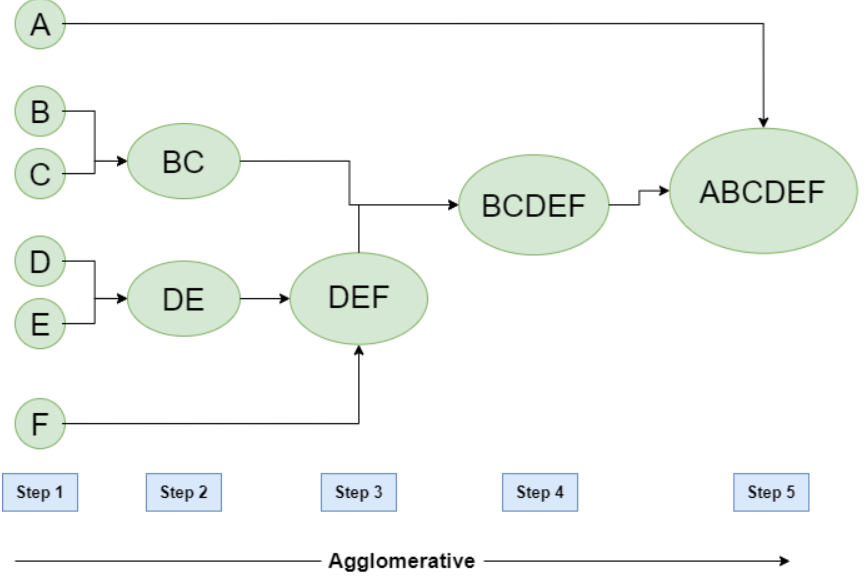
## - **Divisive** (top-down): Start with one big cluster, then split it recursively
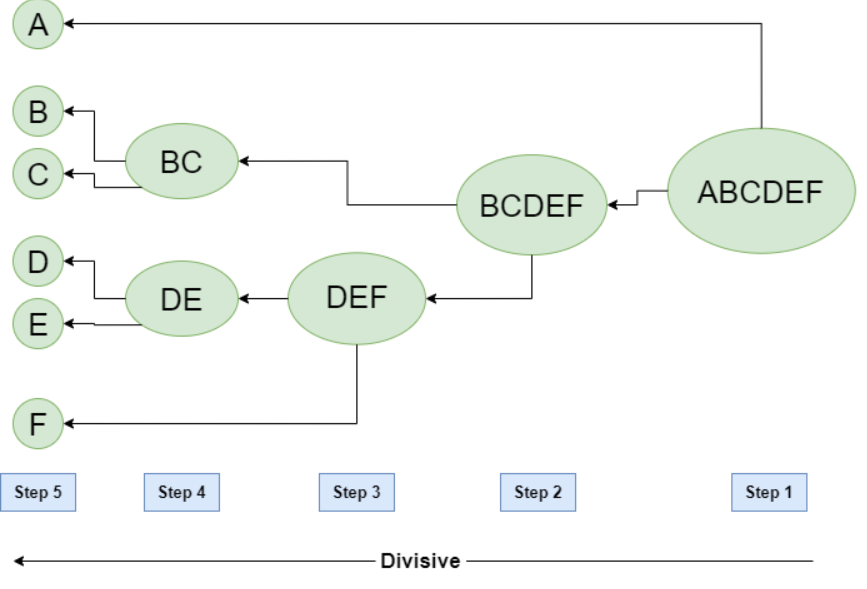
## **Dendrograms** visualize this hierarchy and help you decide the number of clusters.

In [ ]:
# 1. 📥 Import libraries and generate synthetic data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
# Generate blob data (good for hierarchical)
X_blob, y_blob = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=43)

In [ ]:
X_blob

array([[-7.98734885e+00,  1.11361772e+00],
       [ 2.18661339e+00,  5.78447307e-01],
       [ 3.90253307e+00, -1.67161860e+00],
       [-9.74597780e+00,  3.58064777e+00],
       [-4.53952965e+00,  7.69770138e+00],
       [-8.20613913e+00,  3.17148096e+00],
       [-9.22396936e+00, -5.23587759e+00],
       [-2.98531542e+00,  8.44123035e+00],
       [-7.10251949e+00,  2.00193822e+00],
       [-7.71377609e+00,  2.22176690e+00],
       [-3.34776413e+00,  6.54578371e+00],
       [-7.00029733e+00, -4.01751167e+00],
       [-6.79556721e+00, -6.09240874e+00],
       [-3.63937484e+00,  7.53094483e+00],
       [-8.46106944e+00, -4.36494735e+00],
       [ 3.49292355e+00,  1.07404240e+00],
       [ 1.70807629e+00, -4.07758223e-01],
       [-6.84711781e+00,  3.14000422e+00],
       [-7.99021977e+00, -4.68894159e+00],
       [-4.31001146e+00,  6.22499665e+00],
       [-7.07206991e+00,  1.56863294e+00],
       [-8.37791579e+00,  3.71031592e+00],
       [-7.68276186e+00, -5.86738822e+00],
       [-7.

In [ ]:
y_blob

array([3, 3, 0, 2, 3, 2, 1, 2, 0, 1, 0, 1, 0, 0, 3, 0, 3, 1, 0, 0, 1, 0,
       2, 3, 0, 3, 3, 2, 2, 1, 0, 1, 3, 1, 3, 0, 3, 2, 3, 2, 1, 0, 3, 2,
       0, 0, 3, 1, 3, 1, 2, 3, 2, 0, 2, 1, 3, 1, 1, 0, 3, 1, 1, 3, 2, 2,
       2, 2, 2, 0, 2, 2, 3, 1, 0, 3, 2, 2, 0, 2, 0, 0, 3, 0, 2, 3, 3, 1,
       1, 1, 3, 0, 3, 0, 0, 3, 2, 0, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 2, 3,
       1, 0, 0, 0, 0, 1, 3, 2, 3, 2, 2, 2, 0, 3, 2, 3, 3, 0, 3, 2, 1, 0,
       0, 0, 0, 1, 1, 3, 0, 2, 0, 1, 2, 0, 1, 1, 1, 1, 2, 0, 0, 3, 1, 2,
       0, 1, 2, 3, 3, 1, 0, 3, 2, 3, 1, 3, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2,
       2, 1, 1, 2, 3, 0, 3, 1, 1, 3, 2, 0, 1, 1, 2, 2, 2, 3, 1, 2, 2, 1,
       1, 3, 0, 0, 2, 1, 0, 2, 2, 3, 2, 0, 0, 2, 2, 1, 3, 2, 3, 3, 0, 3,
       3, 2, 3, 2, 1, 1, 3, 3, 1, 1, 1, 3, 0, 2, 1, 2, 3, 1, 3, 3, 3, 2,
       2, 1, 3, 2, 2, 2, 3, 2, 3, 2, 3, 1, 2, 3, 1, 0, 3, 0, 1, 0, 3, 0,
       2, 1, 2, 1, 1, 0, 0, 2, 1, 1, 3, 3, 2, 0, 0, 1, 1, 1, 1, 2, 3, 1,
       2, 1, 1, 2, 0, 2, 1, 0, 3, 0, 1, 0, 3, 3])


    make_blobs: This function from scikit-learn's datasets module is used to create isotropic Gaussian blobs for clustering.
    n_samples=300: This specifies that the dataset should contain 300 data points.
    centers=4: This indicates that there should be 4 distinct centers for the blobs, effectively creating 4 clusters.
    cluster_std=1.0: This sets the standard deviation of the clusters. A value of 1.0 means the points within each cluster are relatively spread out.
    random_state=42: This ensures that the data generation is reproducible. If you run the code again with the same random_state, you will get the exact same dataset.
    X_blob, y_blob: The function returns two arrays: X_blob contains the features (the x and y coordinates of the points), and y_blob contains the true cluster labels (0, 1, 2, or 3) for each point.


In [ ]:
# Generate moon data (good for DBSCAN)
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=42)

make_moons: This is a function from scikit-learn's datasets module used to create this specific type of non-linearly separable data.
n_samples=300: This specifies that the dataset should contain 300 data points.
noise=0.1: This adds a small amount of random noise to the data points, making the clusters slightly less perfectly separated and more realistic.

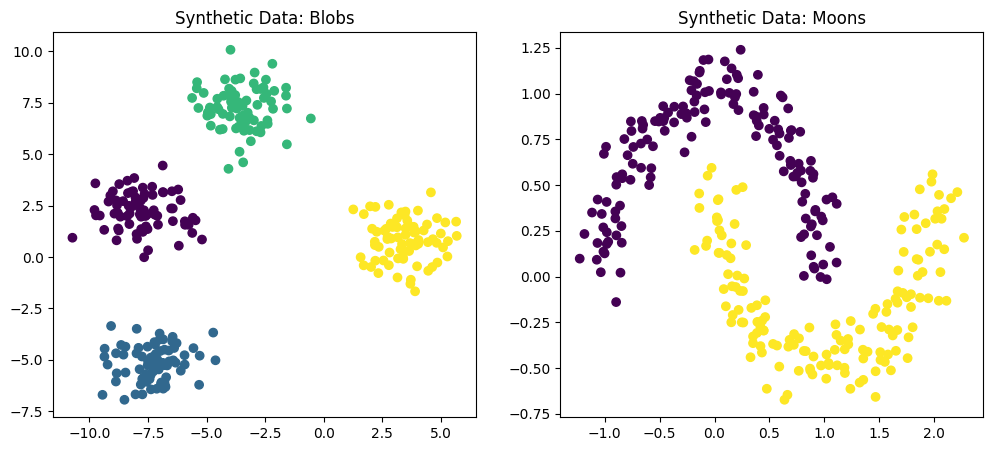

In [ ]:
# Plot both datasets
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='viridis')
axs[0].set_title("Synthetic Data: Blobs")
axs[1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='viridis')
axs[1].set_title("Synthetic Data: Moons")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


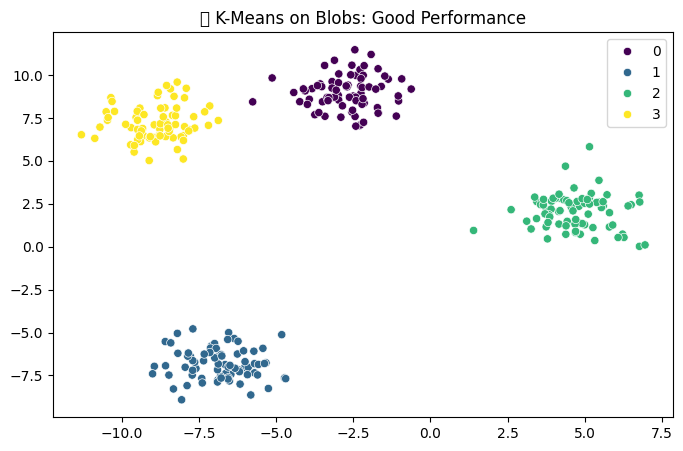

In [ ]:
# 🔎 KMeans on Blobs
Xb_scaled = StandardScaler().fit_transform(X_blob)
kmeans_blob = KMeans(n_clusters=4, random_state=42) # We know there are 4 clusters in the blob data
kmeans_blob_labels = kmeans_blob.fit_predict(Xb_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_blob[:, 0], y=X_blob[:, 1], hue=kmeans_blob_labels, palette='viridis')
plt.title('✅ K-Means on Blobs: Good Performance')
plt.show()

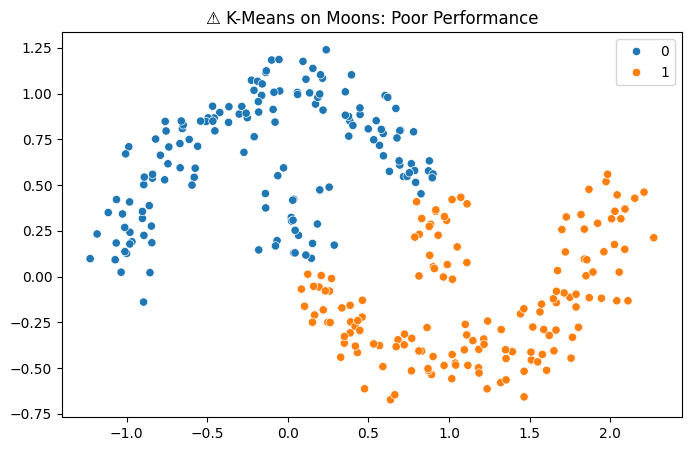

In [ ]:
# 🔍 KMeans struggles on Moons
Xm_scaled = StandardScaler().fit_transform(X_moon)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(Xm_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], hue=kmeans_labels, palette='tab10')
plt.title('⚠️ K-Means on Moons: Poor Performance')
plt.show()


1. Noise
2. Overfit (Kmeans) -> FIlterting  -> Kmeans

1. Kmeans is super slow , prune to overfit , its not good for non spherical data

In [ ]:
# 2. 📈 Hierarchical Clustering on Blobs
Xb_scaled = StandardScaler().fit_transform(X_blob)
linked = linkage(Xb_scaled,method='ward')

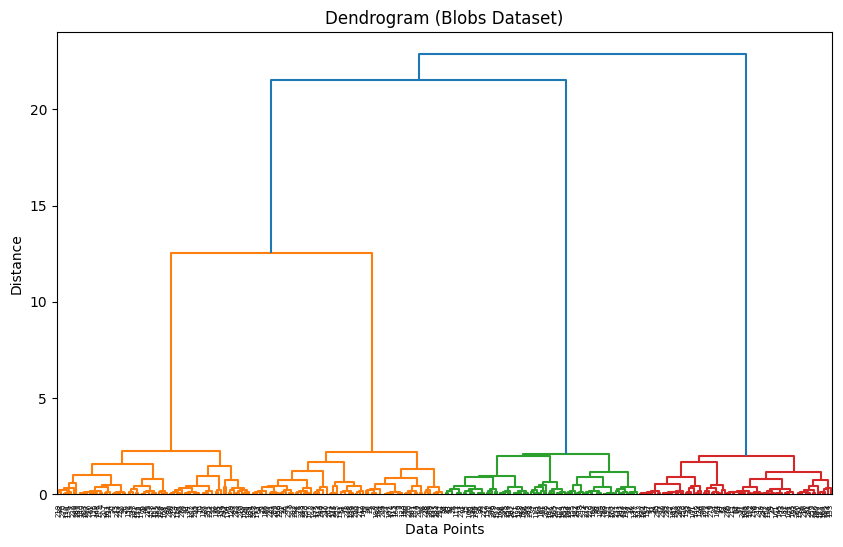

In [ ]:
# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrogram (Blobs Dataset)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Assign clusters
hc_labels = fcluster(linked, t=4, criterion='maxclust')

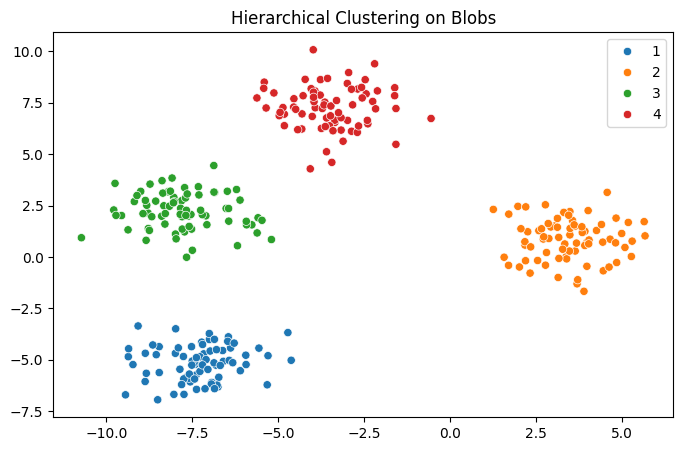

In [ ]:

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_blob[:, 0], y=X_blob[:, 1], hue=hc_labels, palette='tab10')
plt.title('Hierarchical Clustering on Blobs')
plt.show()

1 .noise | overfit

### 📚 Theory: DBSCAN (Density-Based Spatial Clustering)

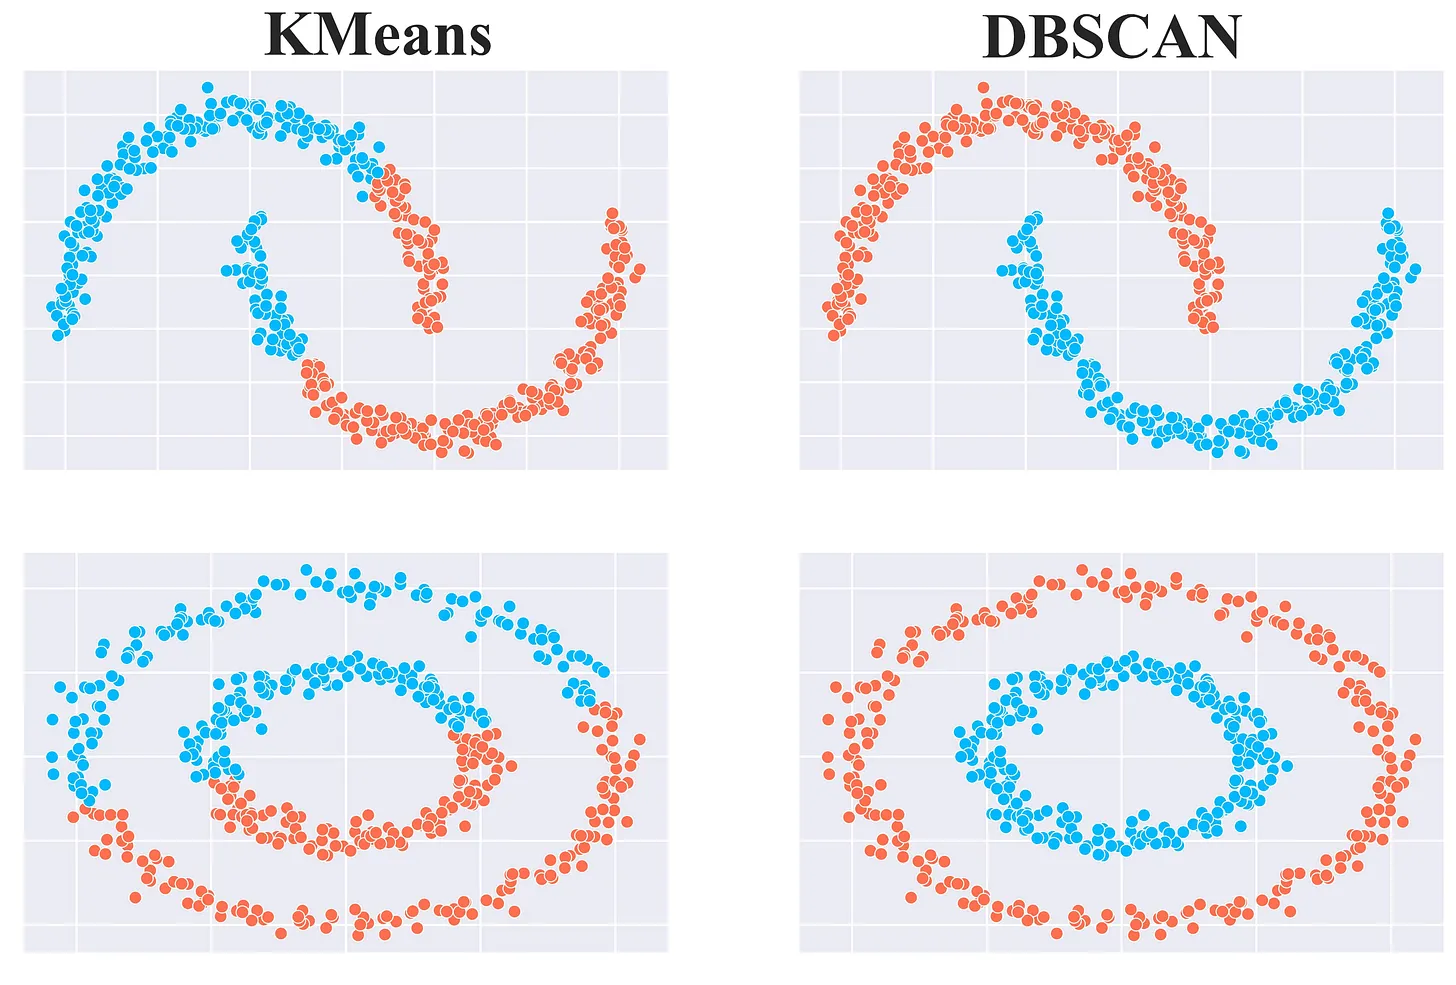
## DBSCAN clusters data based on the density of points:
## - High-density regions form clusters
## - Low-density regions become noise or outliers
## Parameters:
## - `eps`: distance threshold for neighbors
## - `min_samples`: minimum number of neighbors to form a dense region
# Pros:
## - No need to choose number of clusters
## - Can find arbitrarily shaped clusters
## - Identifies noise points

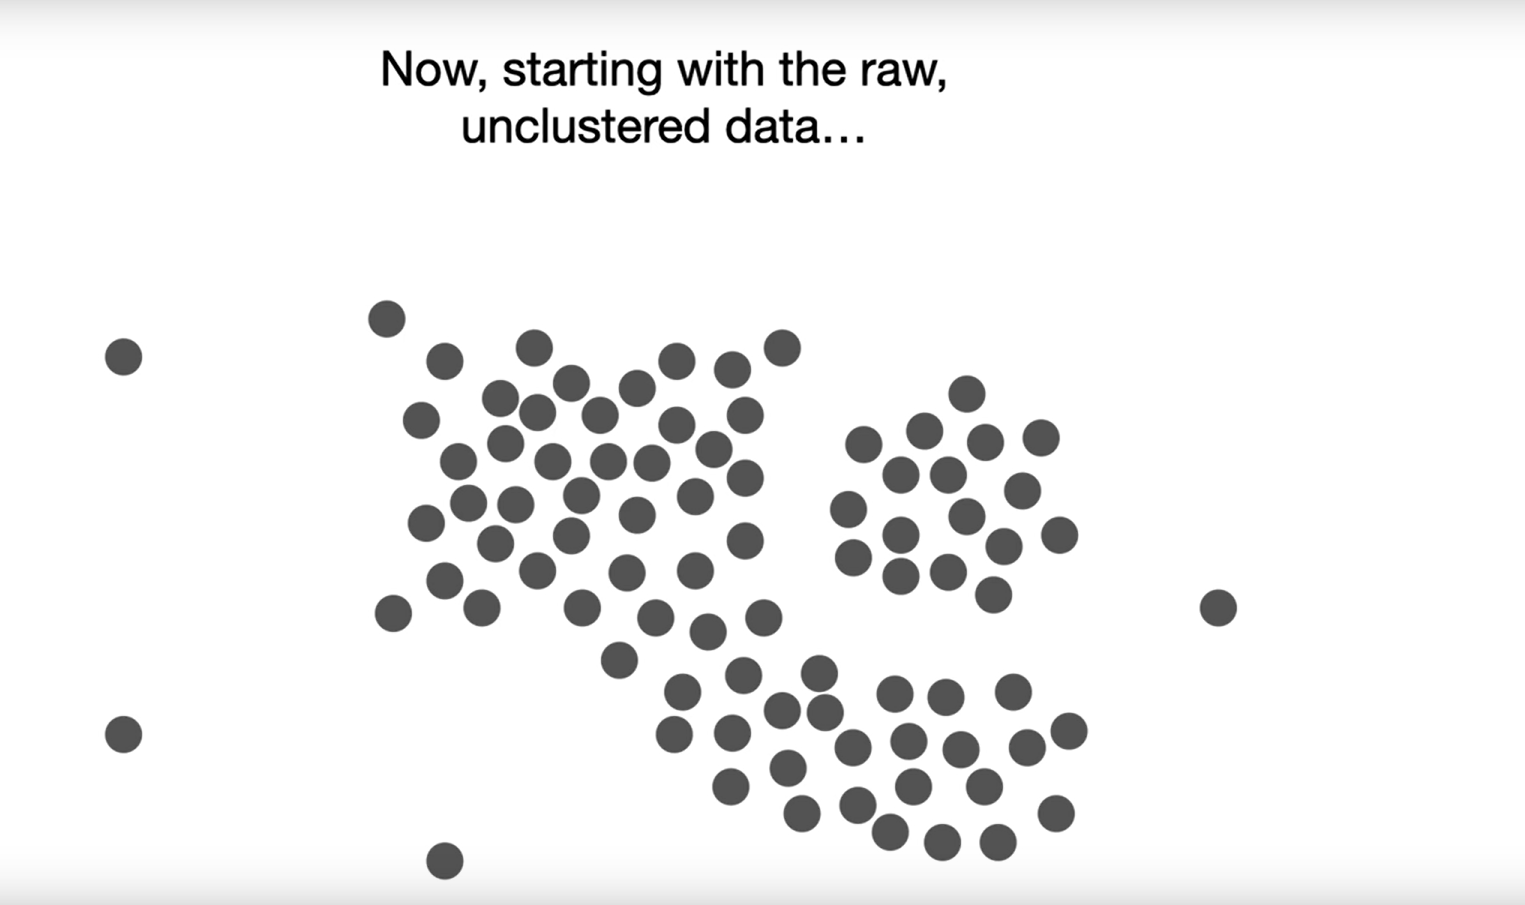

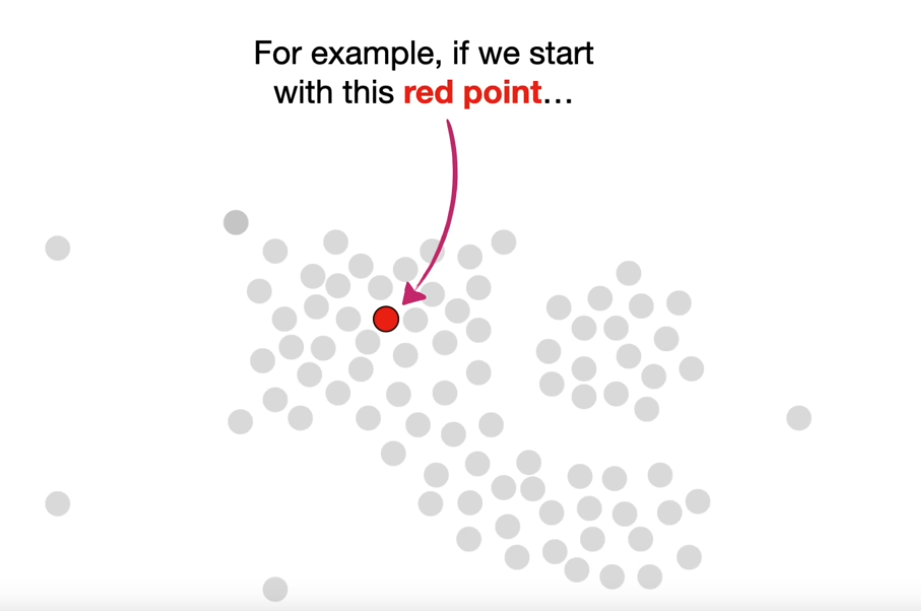

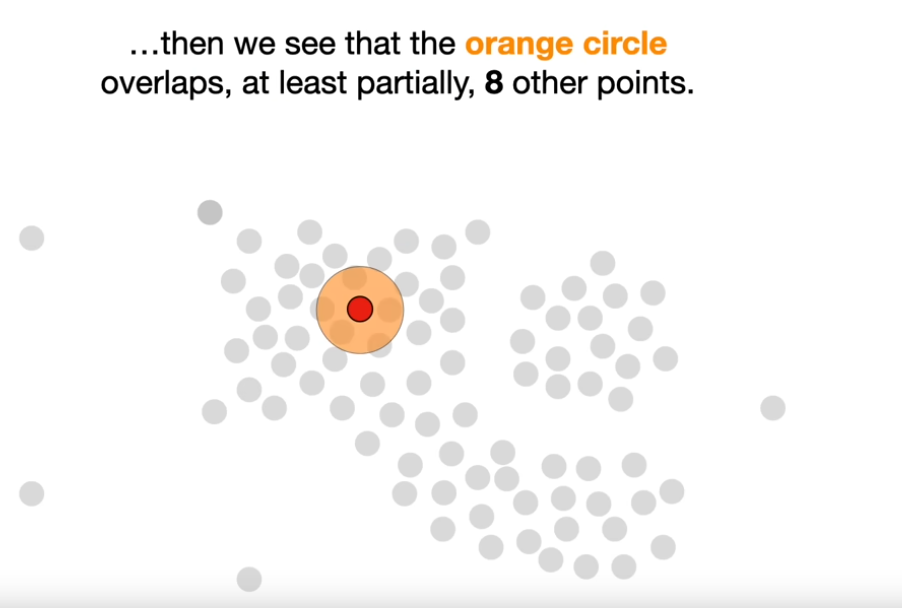

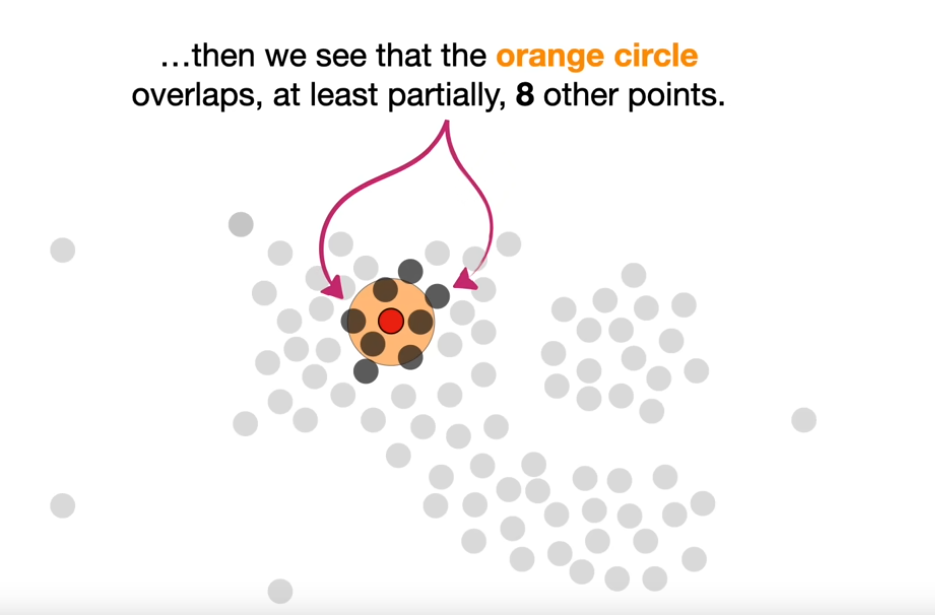

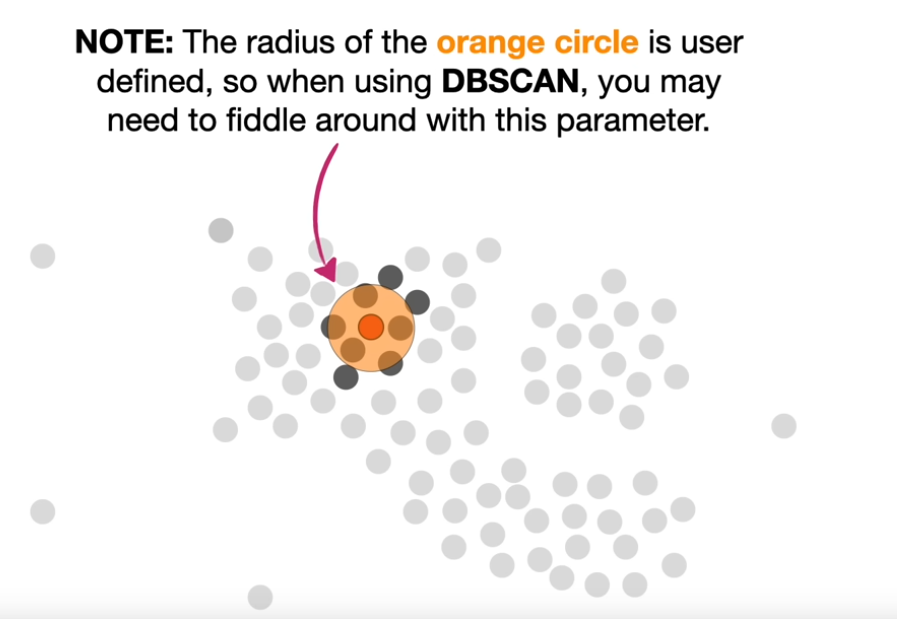

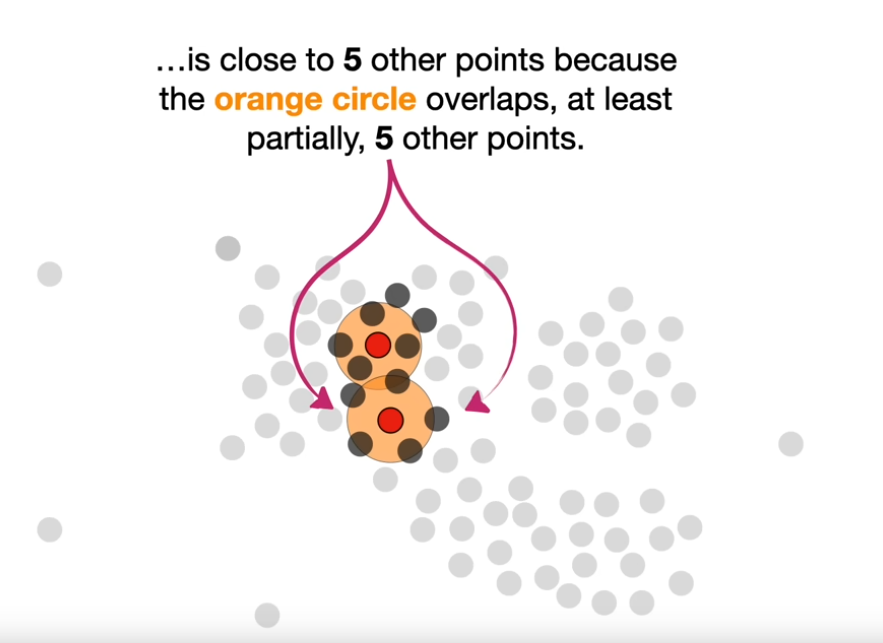

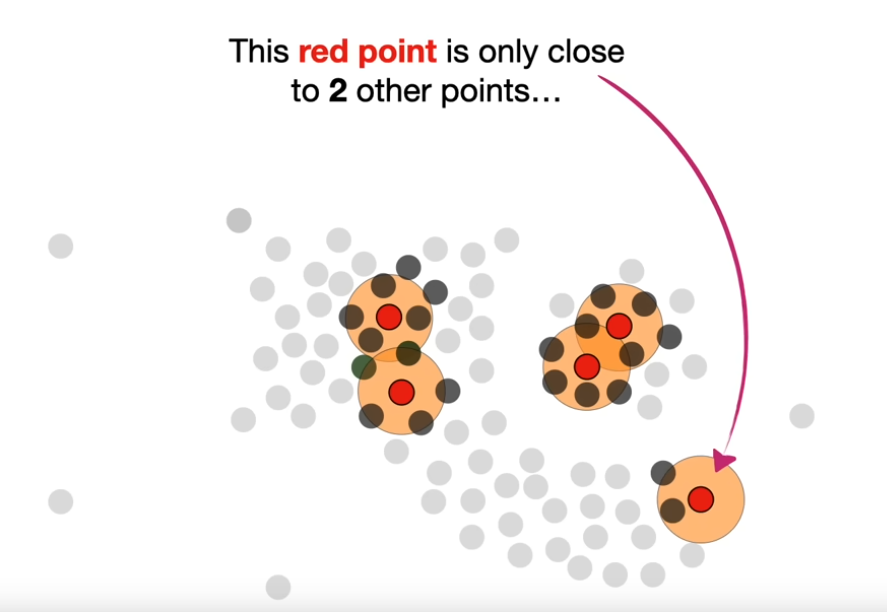

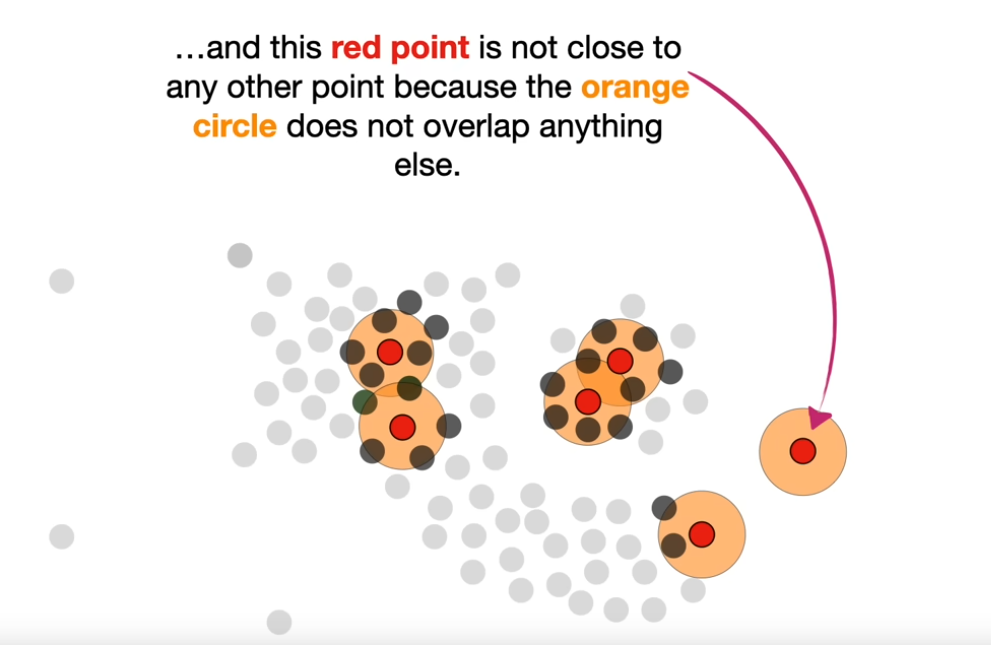

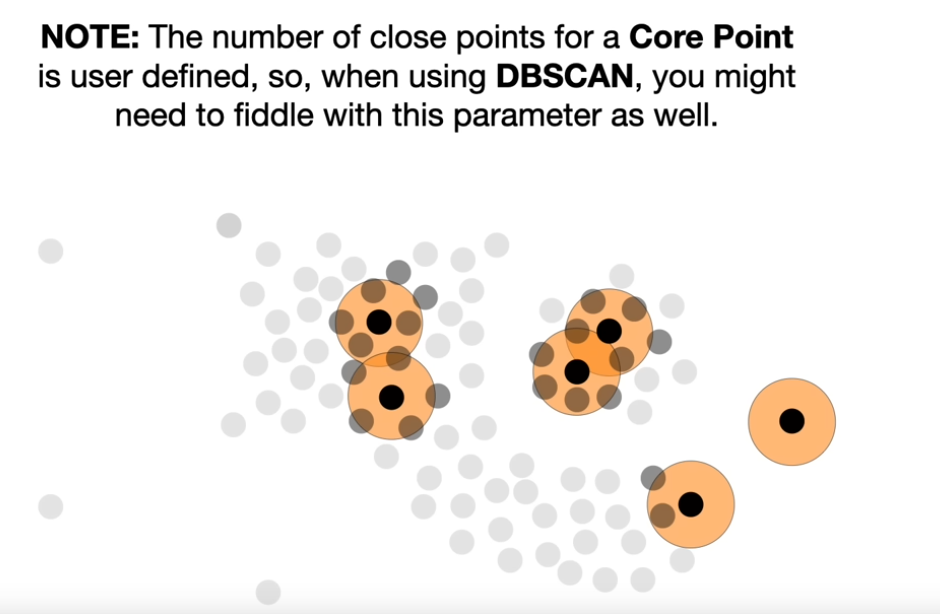


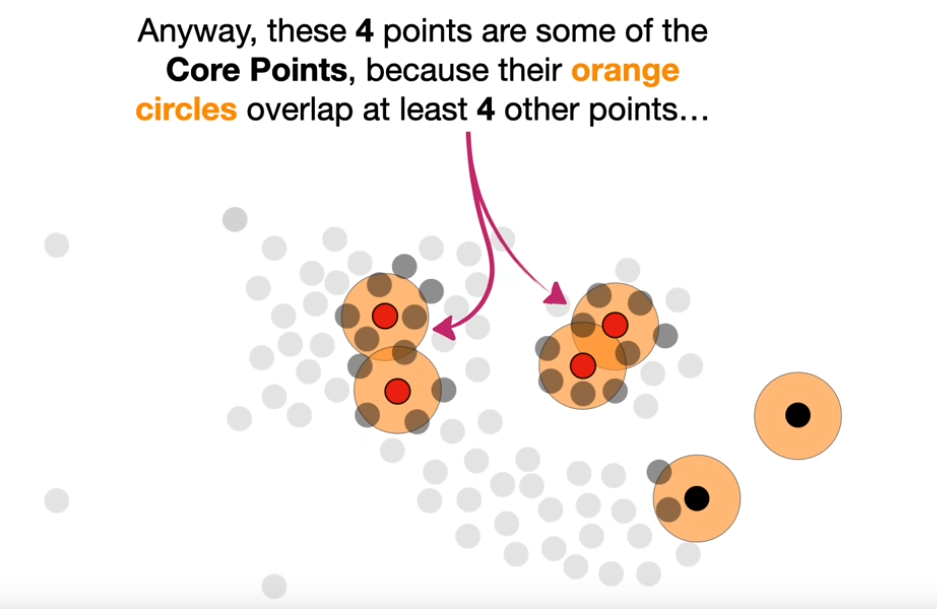

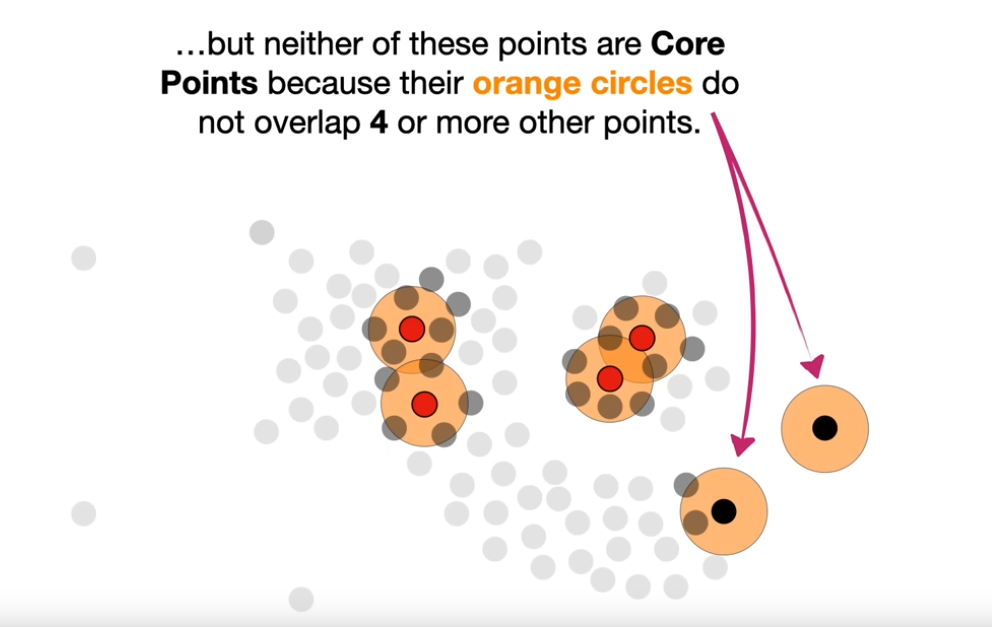

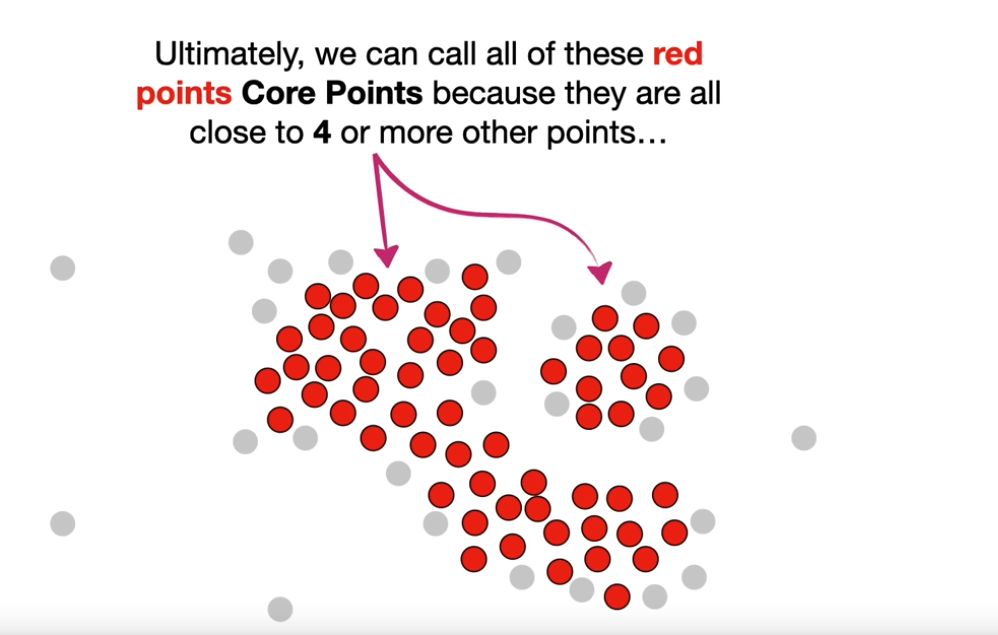


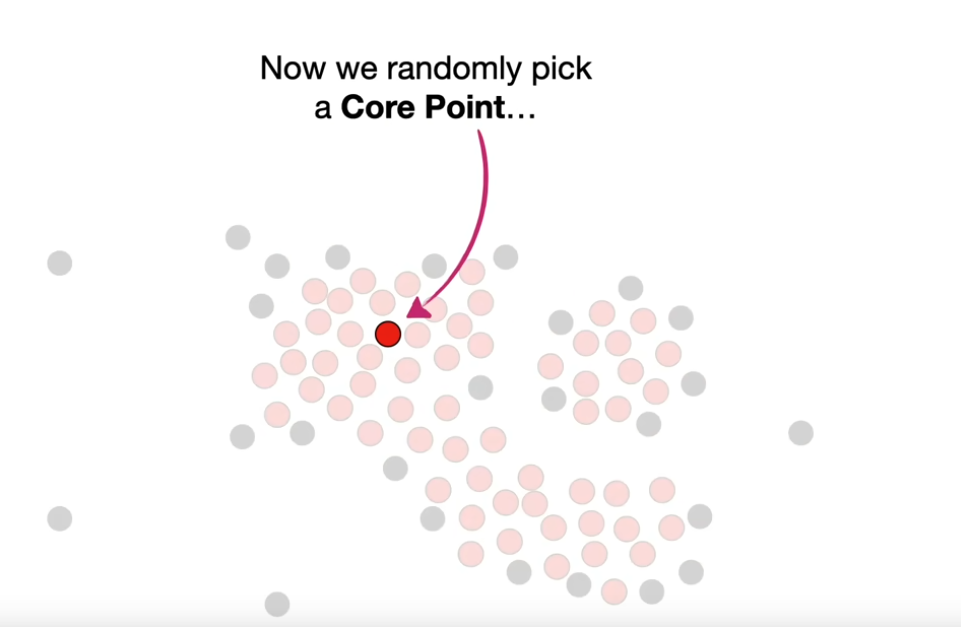

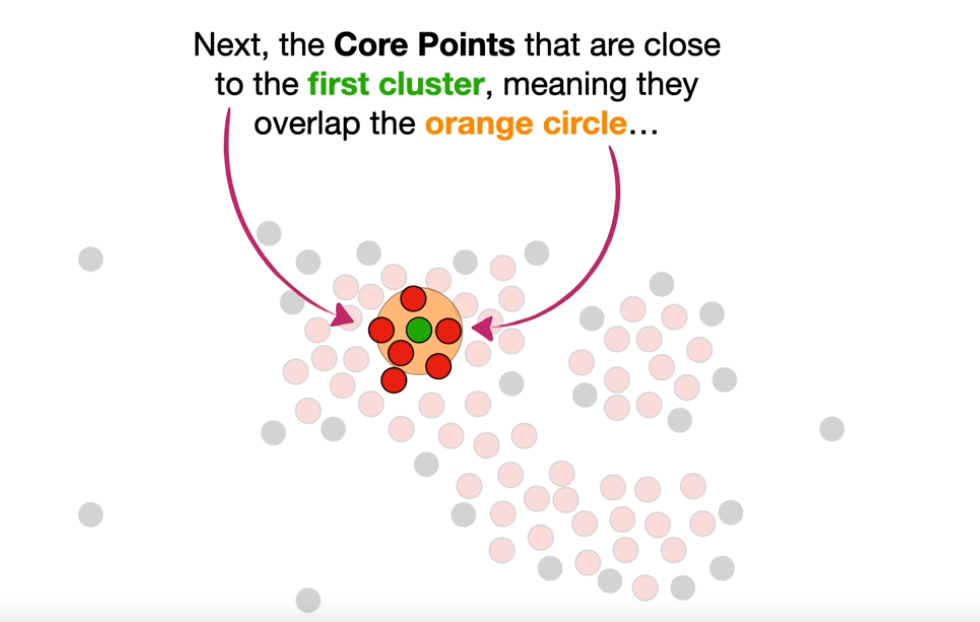

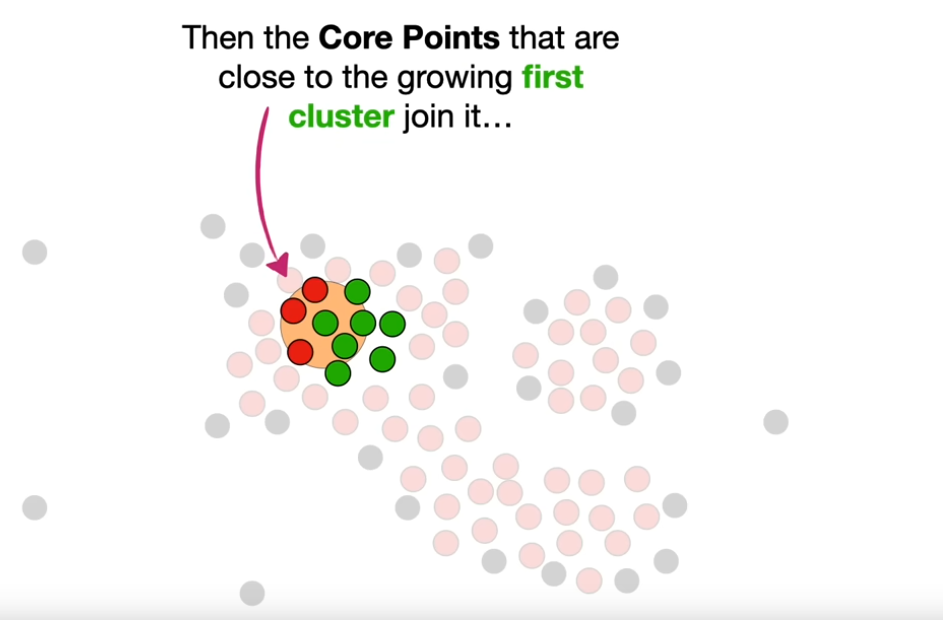

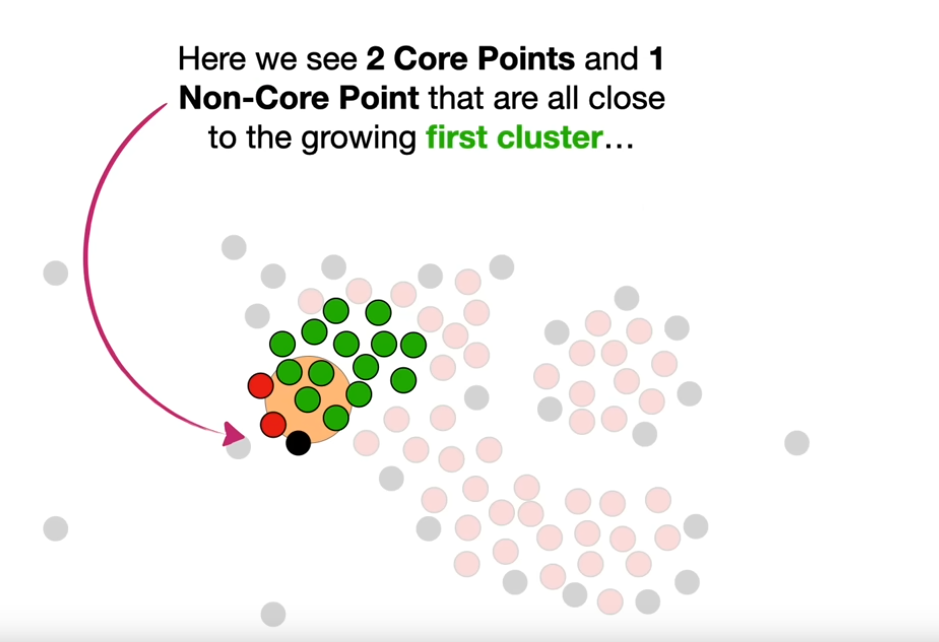

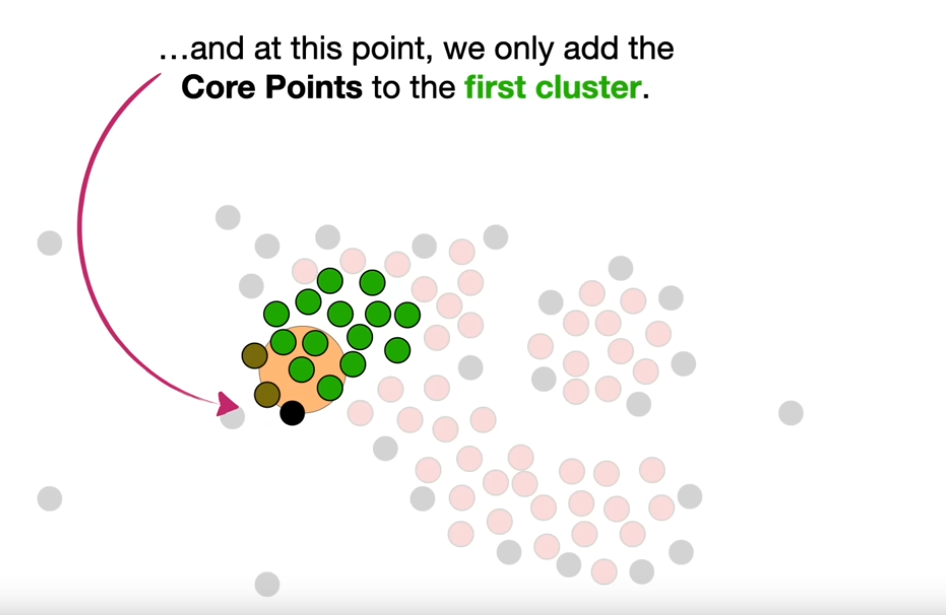

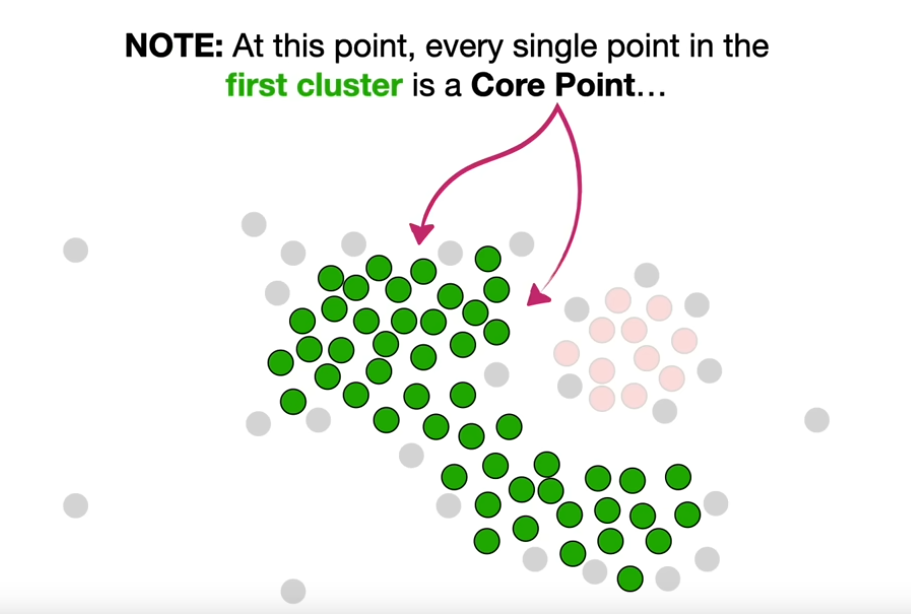

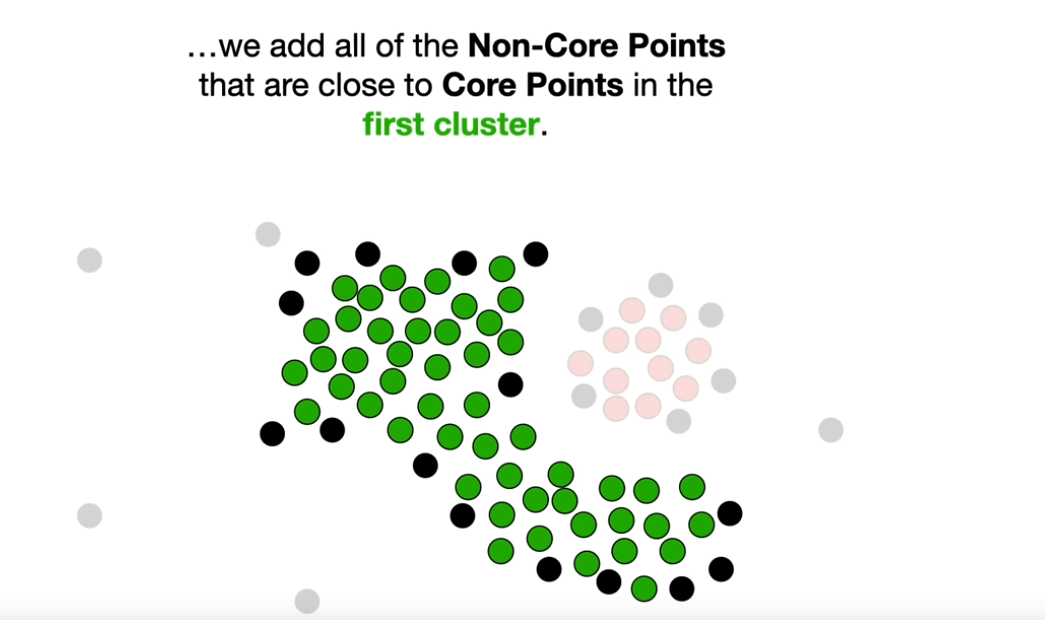

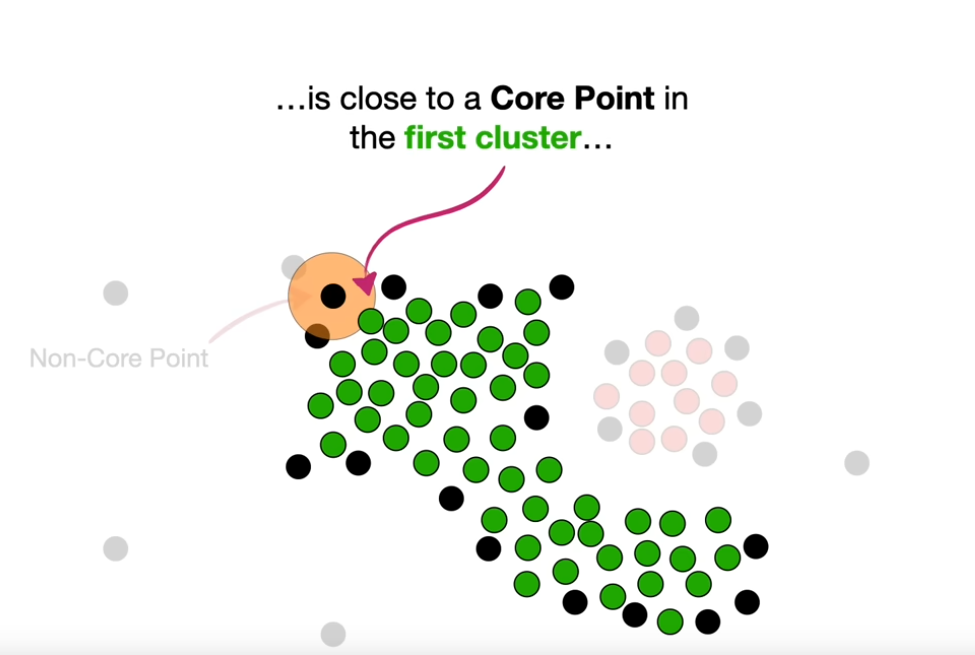

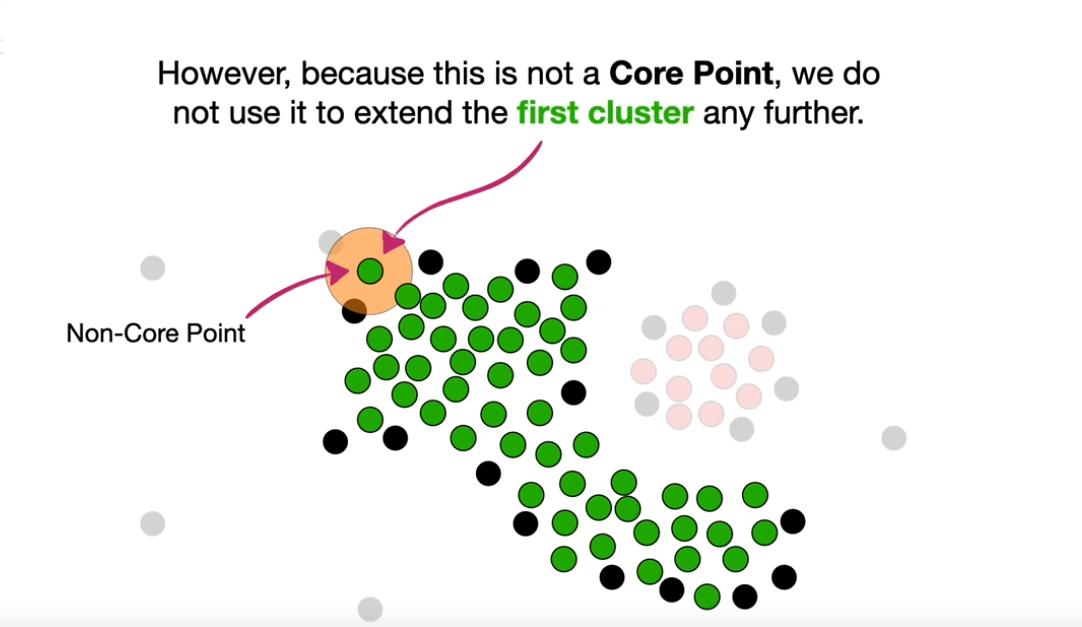

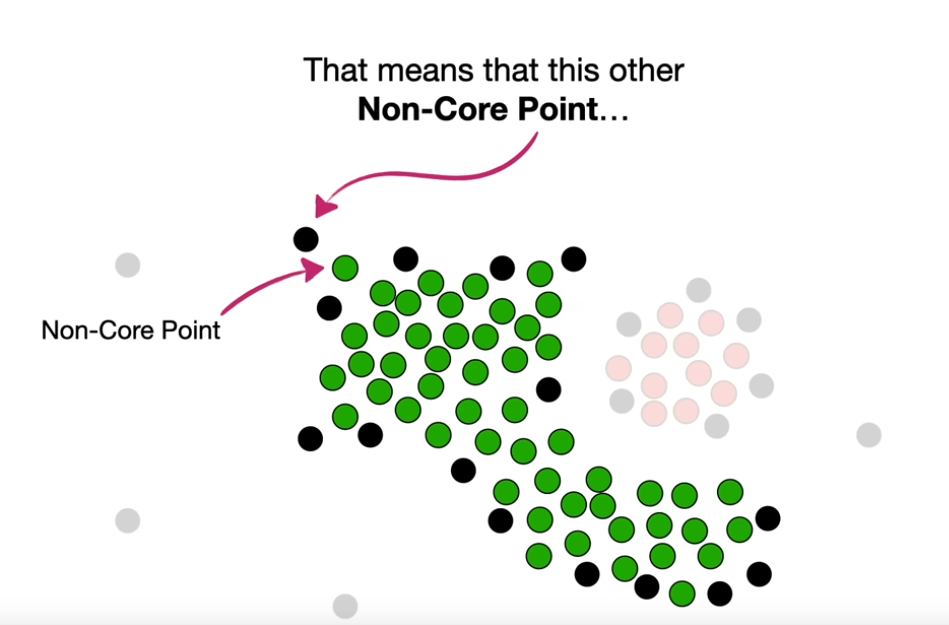

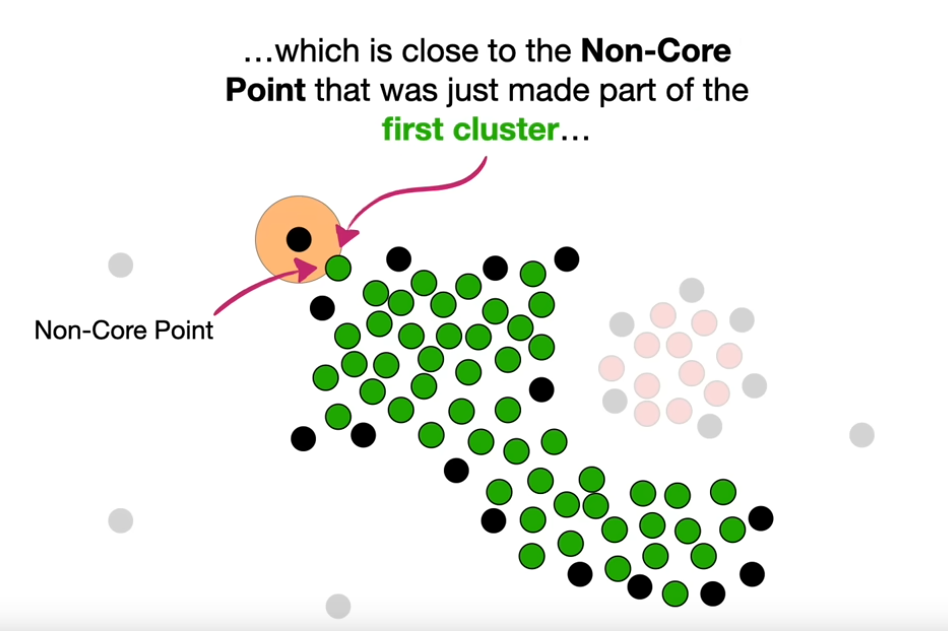


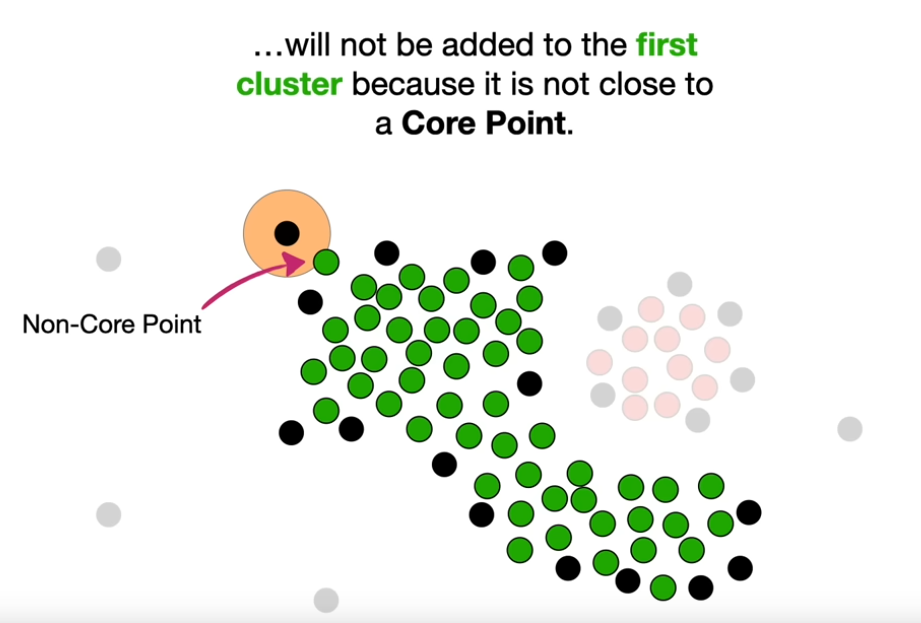

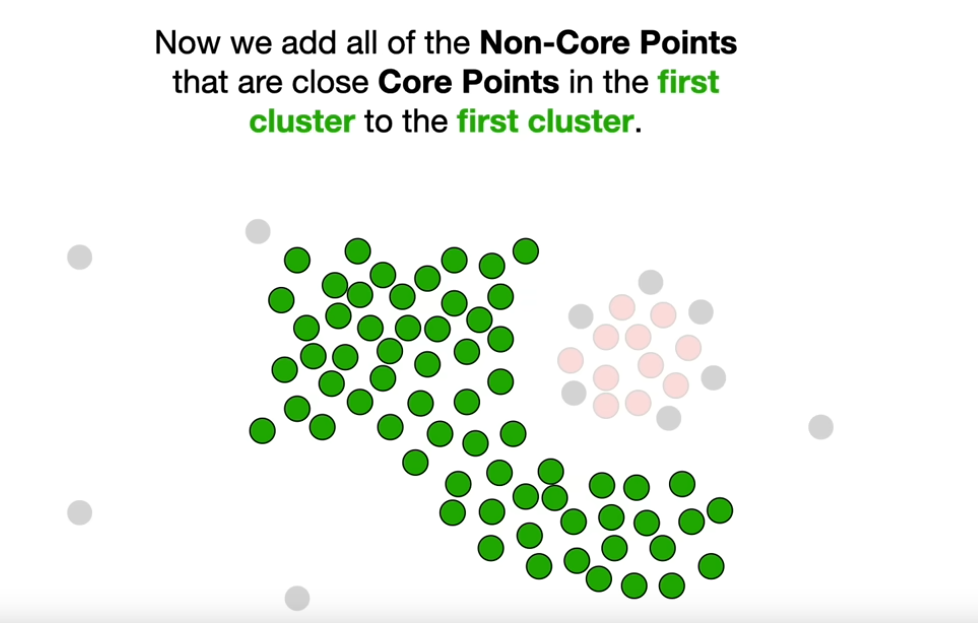

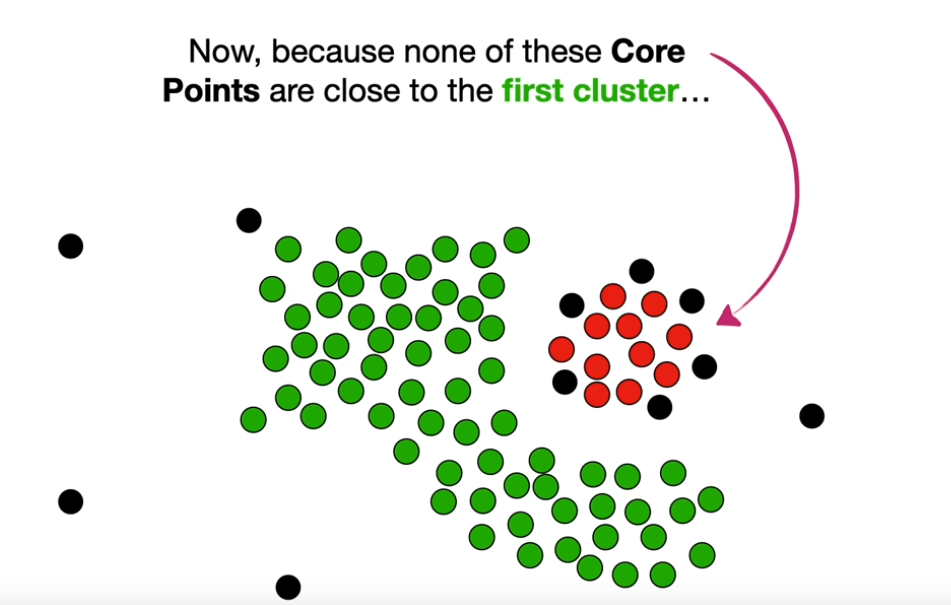



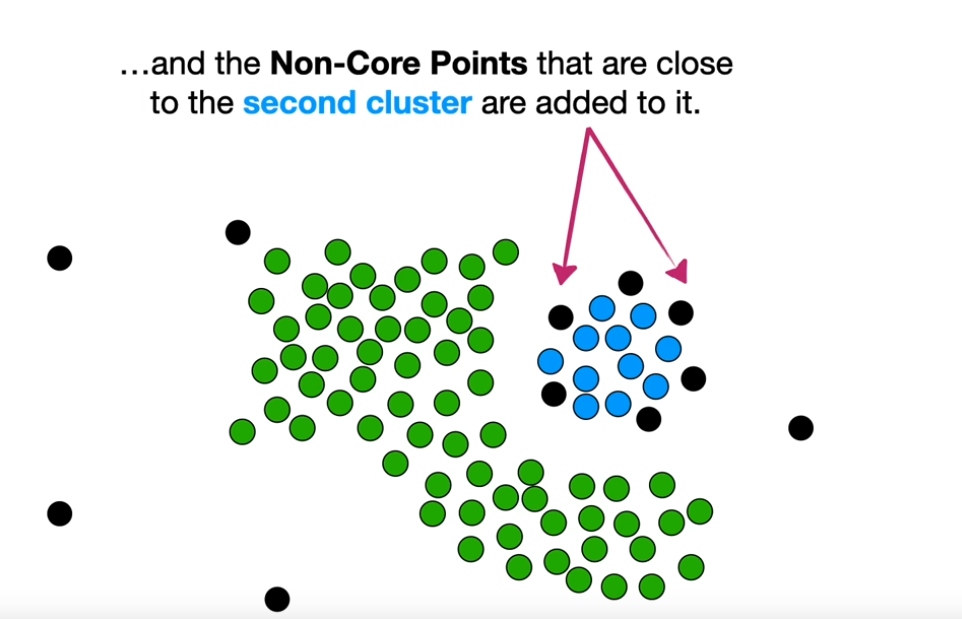

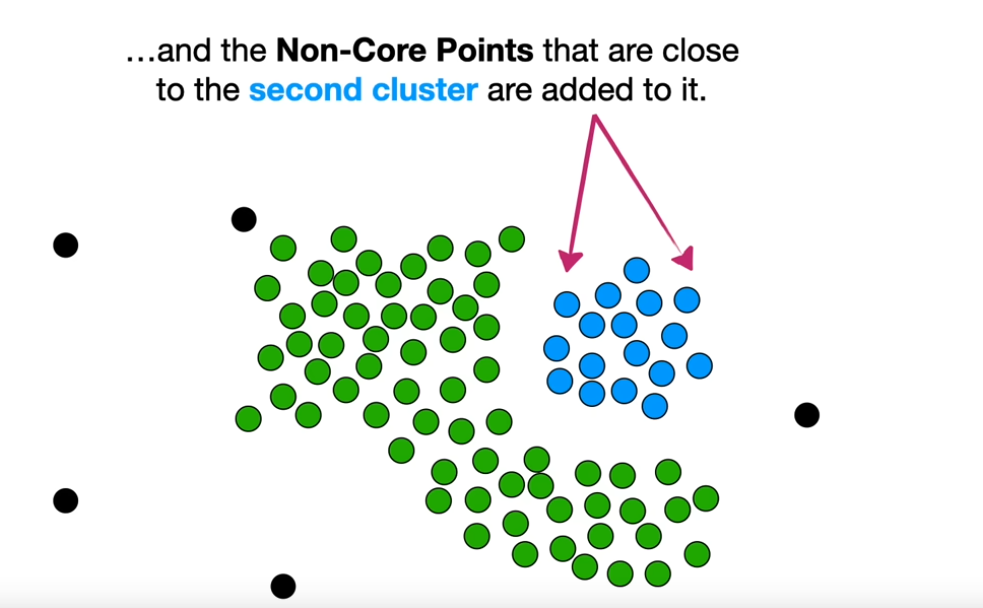



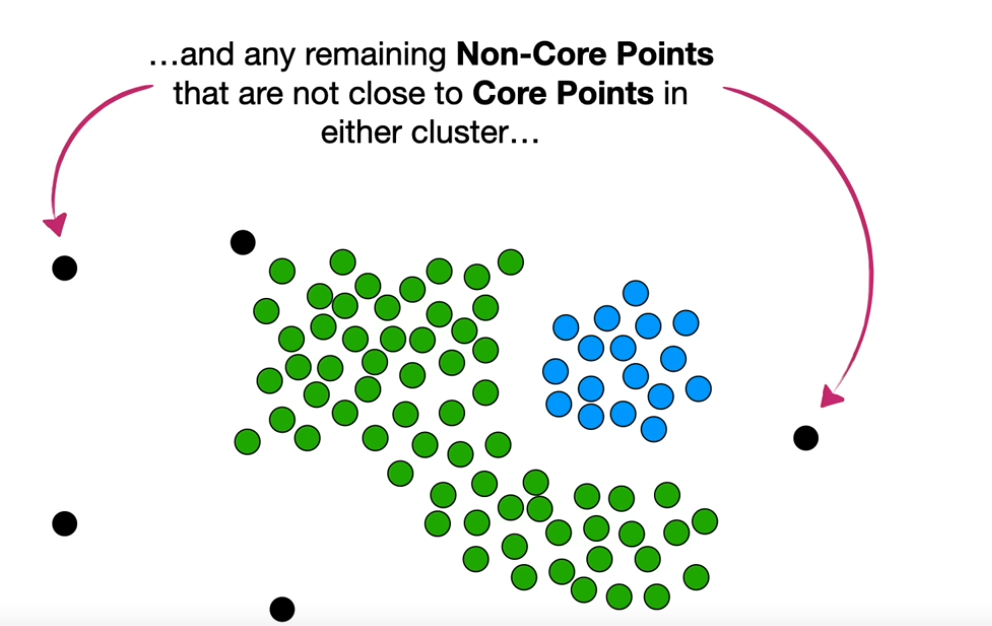

In [ ]:
# Fit DBSCAN [0.3-0.4-0.5]
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(Xm_scaled)


In [ ]:
X_moon[3]

array([0.88574785, 0.28634183])

In [ ]:
db_labels

array([ 0,  0,  0,  1,  0,  0,  0,  1,  1,  0,  0,  1,  0,  1,  0,  0,  0,
        0,  1,  0,  1,  1,  0,  0,  1,  1,  0,  0,  0,  0,  1,  0,  1,  1,
        0,  1,  1,  1,  1,  1,  1,  1,  0,  1,  1,  1,  0,  0,  1,  0,  0,
        1,  0,  1,  0,  0,  1,  1,  0,  1,  0,  1,  1,  0,  0,  1,  1,  0,
        1,  0,  1,  1,  0,  0,  1,  0,  1,  1,  1,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  0, -1,  0,  1,  0,  1,
        1,  0,  0,  0,  1,  1,  0,  1,  1,  0,  1,  0,  0,  1,  1,  0,  0,
        0,  1,  0,  0,  0,  1,  0,  1,  1,  0,  0,  1,  1,  0,  1,  0,  0,
        0,  0,  0,  1,  1,  1,  0,  1, -1,  0,  1,  1,  1,  1,  0,  1,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  0,  1,  1,  1,  1,  0,  0,  0,  1,
        1,  0,  0,  1,  1,  0,  1,  1,  0,  1,  0,  1,  0,  0,  1,  0,  0,
        0,  1,  1,  1,  0,  0,  0,  0,  1,  0,  0,  1,  0,  1,  1,  1,  0,
        0,  0,  0,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  0,  0,  1,  1,
        0,  0,  0,  1,  0

In [ ]:
X_moon[0]

array([ 0.68298822, -0.34520334])

In [ ]:
X_moon[1]

array([ 2.04099043, -0.13161467])

In [ ]:
X_moon[:2,1]

array([-0.34520334, -0.13161467])

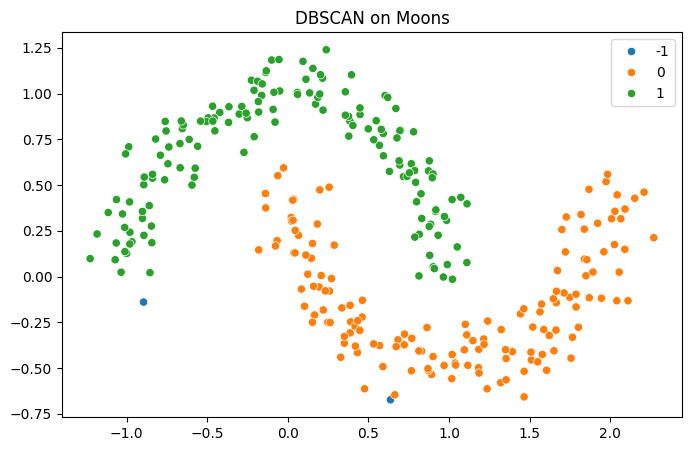

In [ ]:
# Visualize DBSCAN result
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], hue=db_labels, palette='tab10')
plt.title('DBSCAN on Moons')
plt.show()


In [ ]:
amount , Transaction time , ...

PCA ->2/3 (Variance)

Dbscan (Noise) -> Fruad



In [ ]:

# ✅ Summary Table
from IPython.display import display, Markdown

display(Markdown("""
| Algorithm              | Needs K? | Handles Outliers? | Handles Non-Spherical? |
|------------------------|----------|--------------------|-------------------------|
| K-Means                | ✅ Yes   | ❌ No              | ❌ No                  |
| Hierarchical Clustering| ✅ Yes   | ❌ No              | ❌ No                  |
| DBSCAN                 | ❌ No    | ✅ Yes             | ✅ Yes                 |

- Use **Hierarchical** when you want interpretability and dendrograms
- Use **DBSCAN** when you want to detect noise or clusters of arbitrary shape
"""))


| Algorithm              | Needs K? | Handles Outliers? | Handles Non-Spherical? |
|------------------------|----------|--------------------|-------------------------|
| K-Means                | ✅ Yes   | ❌ No              | ❌ No                  |
| Hierarchical Clustering| ✅ Yes   | ❌ No              | ❌ No                  |
| DBSCAN                 | ❌ No    | ✅ Yes             | ✅ Yes                 |

- Use **Hierarchical** when you want interpretability and dendrograms
- Use **DBSCAN** when you want to detect noise or clusters of arbitrary shape
